# QVAE

Reimplements the core model from [gersteinlab/QVAE](https://github.com/gersteinlab/QVAE),
mirroring the structure of `vae.ipynb` / `svae.ipynb` / `poisson_vae.ipynb` (data → model →
train → sample → reconstructions → interpolations).

The official repo is a Qiskit 0.43 / `qiskit-machine-learning` research script built around
gradient-free optimizers (COBYLA/SPSA) acting on `DensityMatrix` objects, tied to its own
swiss-roll/gene datasets and file-based CLI (`QVAE.py`, `core.py`, `embedding.py`). It is not
pip-installable against current Qiskit and predates this survey's MNIST/PyTorch baseline, so
instead of importing it directly this notebook ports its load-bearing pieces — the
Ising-interaction encoder/decoder ansatz (`embedding.py::ising_interaction_noInput`), the
trash-qubit bottleneck via partial trace (`core.py::QVAE_NN.forward`), and the
fidelity-reconstruction / JSD-regularizer objective against the maximally mixed state
(`core.py::DensityMatrix_ObjectiveFunction`) — as plain `torch` tensor ops, verbatim in spirit,
wired into the same MNIST pipeline used elsewhere in this survey. Since every op used (RZZ/RY
rotations, partial trace, fidelity, matrix log) is differentiable, we train with Adam instead
of the original COBYLA — a practical swap that keeps the model's math unchanged.

A **quantum autoencoder** here plays the role of a VAE: the encoder is a parameterized unitary
acting on the input state, some of its qubits ("trash qubits") are traced out to form an
information bottleneck (the latent), and a regularizer pulls the traced-out latent state
toward the maximally mixed state — the quantum analogue of a VAE's KL-to-standard-normal term.
The decoder is a second parameterized unitary that re-expands the latent (padded with a fixed
`|0...0>` reconstruction register) back to the input dimension.

In [1]:
import math
import torch
import torch.nn as nn
import torchvision.datasets as datasets

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float64)  # unitary/fidelity math is numerically sensitive

## Data

Same MNIST split used by `vae.ipynb`, but amplitude-encoded into pure quantum states rather
than kept as pixel intensities. Qiskit simulation of dense two-qubit gates on all pairs is
exponential in qubit count, so — matching the original repo's small swiss-roll/gene inputs
(8 and 16 features) — we downsample each 28x28 image to 8x8=64=2^6 pixels (`n_qubit=6`) and
L2-normalize each flattened image to a unit vector, exactly `preprocessing.py::normalize_amplitude`.
A unit vector `x` is then a valid quantum statevector, and `|x><x|` (`core.py` builds inputs
with `qi.DensityMatrix(x).data`) is its density matrix.

In [2]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

n_qubit = 6
res = 2 ** (n_qubit // 2)  # 8x8 = 64 = 2^6

def to_amplitude_states(images):
    x = images.reshape(-1, 1, 28, 28).double() / 255.
    x = nn.functional.adaptive_avg_pool2d(x, (res, res)).reshape(-1, res * res)
    x = x + 1e-6  # avoid an exact all-zero (unnormalizable) state
    x = x / x.norm(dim=1, keepdim=True)
    return x

train_dataset = to_amplitude_states(mnist_trainset.data[:-10000])
eval_dataset = to_amplitude_states(mnist_trainset.data[-10000:])

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.48MB/s]


## Ising-interaction ansatz

Ported from `embedding.py::ising_interaction_noInput`: `n_layers` blocks of an all-pairs `RZZ`
entangling layer followed by a per-qubit `RY` rotation. Built here as dense `2^n x 2^n` unitary
matrices (Kronecker products of single-/two-qubit gates) acting on density matrices by
conjugation, `rho -> U rho U^dagger`, which is what `core.py`'s `DensityMatrix.evolve(qc)` does
under the hood.

In [3]:
def embed_gate(gate, qubit, n_qubits):
    """gate: (2, 2) complex tensor already on the target device."""
    eye = torch.eye(2, dtype=torch.complex128, device=gate.device)
    mats = [eye] * n_qubits
    mats[qubit] = gate
    out = mats[0]
    for m in mats[1:]:
        out = torch.kron(out, m)
    return out

def ry_gate(theta):
    c, s = torch.cos(theta / 2), torch.sin(theta / 2)
    return torch.stack([torch.stack([c, -s]), torch.stack([s, c])]).to(torch.complex128)

def rzz_unitary(theta, q1, q2, n_qubits):
    device = theta.device
    z = torch.tensor([[1, 0], [0, -1]], dtype=torch.complex128, device=device)
    zz = embed_gate(z, q1, n_qubits) @ embed_gate(z, q2, n_qubits)
    dim = 2 ** n_qubits
    eye = torch.eye(dim, dtype=torch.complex128, device=device)
    # exp(-i*theta/2*ZZ) with ZZ diagonal +-1 -> cos(theta/2)*I - i*sin(theta/2)*ZZ
    return torch.cos(theta / 2) * eye - 1j * torch.sin(theta / 2) * zz

def ising_interaction_unitary(theta, n_layers, n_qubits):
    """theta: 1D real tensor of length n_layers * (n_qubits*(n_qubits-1)/2 + n_qubits)."""
    dim = 2 ** n_qubits
    U = torch.eye(dim, dtype=torch.complex128, device=theta.device)
    idx = 0
    for _ in range(n_layers):
        for q1 in range(n_qubits):
            for q2 in range(q1 + 1, n_qubits):
                U = rzz_unitary(theta[idx], q1, q2, n_qubits) @ U
                idx += 1
        for q in range(n_qubits):
            U = embed_gate(ry_gate(theta[idx]).to(theta.device), q, n_qubits) @ U
            idx += 1
    return U

def num_ising_params(n_layers, n_qubits):
    return n_layers * (n_qubits * (n_qubits - 1) // 2 + n_qubits)

## Partial trace

Ported from the repeated `qi.partial_trace(state, qubits)` + renormalize pattern in
`core.py::QVAE_NN.forward`, used both to trace out the trash qubits (encoder -> latent
bottleneck) and to trace out auxiliary qubits after the decoder unitary.

In [4]:
def batched_partial_trace_keep(rho, keep, n_qubits):
    """Trace out all qubits of a batch of n_qubits density matrices except `keep`.

    rho: (B, 2^n_qubits, 2^n_qubits). Vectorized over the batch dimension B (no Python loop
    over samples) since B is the axis this notebook's batch size actually scales.
    """
    trace_out = [q for q in range(n_qubits) if q not in keep]
    b = rho.size(0)
    dims = [2] * n_qubits
    rho_t = rho.reshape([b] + dims + dims)
    # ket axes are 1..n_qubits, bra axes are n_qubits+1..2*n_qubits (axis 0 is the batch dim)
    for q in sorted(trace_out, reverse=True):
        ket_axis = 1 + q
        bra_axis = 1 + q + n_qubits
        rho_t = torch.diagonal(rho_t, dim1=ket_axis, dim2=bra_axis, offset=0).sum(-1)
        # torch.diagonal moves the summed axis to the end; rebuild bookkeeping
        n_qubits -= 1
        dims = dims[:q] + dims[q + 1:]
        rho_t = rho_t.reshape([b] + dims + dims)
    dim = 2 ** len(keep)
    rho_out = rho_t.reshape(b, dim, dim)
    trace = rho_out.diagonal(dim1=-2, dim2=-1).sum(-1).real
    return rho_out / trace.view(-1, 1, 1)

## Model

`n_qubit=6` total, with `n_trash` qubits (default 2, matching the original's
`--num_trash_qubits`) traced out after the encoder to form the latent bottleneck (`n_qubit -
n_trash` qubits). The decoder pads the latent back out with a fixed `|0...0><0...0|`
"reconstruction register" of `n_trash` qubits (`core.py`'s `zero_state` /
`reconstruction_qubits`) before applying its own Ising-interaction unitary, and the output is
read straight off the full `n_qubit`-qubit density matrix (no auxiliary qubits, matching the
default `num_auxiliary_encoder=num_auxiliary_decoder=0`).

In [5]:
class QVAE(nn.Module):
    def __init__(self, n_qubit=6, n_trash=2, n_layers=3):
        super().__init__()
        self.n_qubit = n_qubit
        self.n_trash = n_trash
        self.n_latent = n_qubit - n_trash
        self.n_layers = n_layers

        n_params = num_ising_params(n_layers, n_qubit)
        self.encoder_theta = nn.Parameter(0.1 * torch.randn(n_params))
        self.decoder_theta = nn.Parameter(0.1 * torch.randn(n_params))
        self.n_latent_dim = 2 ** self.n_latent

        zero = torch.zeros(2 ** n_trash, 2 ** n_trash, dtype=torch.complex128)
        zero[0, 0] = 1.0
        self.register_buffer("reconstruction_register", zero)

    def encode(self, rho):
        """rho: (B, 2^n_qubit, 2^n_qubit) input density matrices -> (B, 2^n_latent, ...) latents."""
        U = ising_interaction_unitary(self.encoder_theta, self.n_layers, self.n_qubit)
        evolved = U @ rho @ U.conj().T
        latent_qubits = list(range(self.n_trash, self.n_qubit))  # trace out the first n_trash
        return batched_partial_trace_keep(evolved, latent_qubits, self.n_qubit)

    def decode(self, latent):
        """latent: (B, 2^n_latent, ...) -> (B, 2^n_qubit, ...) reconstructed density matrices."""
        b = latent.size(0)
        reg = self.reconstruction_register
        # batched kron(reg, latent[i]) via an outer-product-of-blocks reshape, avoiding a
        # Python loop over the batch dimension
        full = reg[None, :, None, :, None] * latent[:, None, :, None, :]
        full = full.reshape(b, reg.size(0) * self.n_latent_dim, reg.size(0) * self.n_latent_dim)
        U = ising_interaction_unitary(self.decoder_theta, self.n_layers, self.n_qubit)
        return U @ full @ U.conj().T

    def forward(self, rho):
        latent = self.encode(rho)
        recon = self.decode(latent)
        return recon, latent

## Objective: fidelity reconstruction + JSD regularizer

Ported from `core.py::DensityMatrix_ObjectiveFunction`: `objective = reconstruction_loss +
beta * quantum_relative_entropy`. We use the repo's default `reconstruction_loss='fidelity'`
(negative mean quantum state fidelity between input and output) and `regularizer_type='JSD'`
(mean Jensen-Shannon divergence between each latent state and the maximally mixed state
`I/2^n_latent`) — the quantum analogue of a VAE's `-fidelity` reconstruction term and
`KL(q(z|x) || p(z))` prior term. `beta` is linearly annealed from 0 to 1 as in the other
notebooks in this survey.

In [6]:
def state_fidelity(rho, sigma):
    """Uhlmann fidelity, batched over a leading (...) dimension: F = (tr sqrt(sqrt(rho) sigma sqrt(rho)))^2.

    torch.linalg.eigh/eigvalsh operate on the trailing two dims and are already batched, so
    this needs no Python loop over the batch.
    """
    evals, evecs = torch.linalg.eigh(rho)
    evals = evals.clamp(min=0).to(torch.complex128)
    sqrt_rho = evecs @ torch.diag_embed(evals.sqrt()) @ evecs.conj().transpose(-2, -1)
    inner = sqrt_rho @ sigma @ sqrt_rho
    inner = (inner + inner.conj().transpose(-2, -1)) / 2  # enforce Hermitian
    inner_evals = torch.linalg.eigvalsh(inner).clamp(min=0)
    return inner_evals.sqrt().sum(-1) ** 2

def von_neumann_entropy(rho):
    evals = torch.linalg.eigvalsh(rho).clamp(min=1e-12)
    return -(evals * evals.log2()).sum(-1)

def reconstruction_loss(recon, target):
    return -state_fidelity(recon, target).real.mean()

def jsd_regularizer(latent):
    dim = latent.size(-1)
    max_mixed = torch.eye(dim, dtype=torch.complex128, device=latent.device) / dim
    max_mixed_b = max_mixed.expand_as(latent)
    m = 0.5 * (latent + max_mixed_b)
    ent_latent = von_neumann_entropy(latent)
    ent_mixed = von_neumann_entropy(max_mixed)
    ent_m = von_neumann_entropy(m)
    # JSD(a||b) = H(0.5a+0.5b) - 0.5*H(a) - 0.5*H(b), matching core.py's sign convention (minimized)
    jsd = ent_m - 0.5 * ent_latent - 0.5 * ent_mixed
    return jsd.mean()

## Training

Batched over density matrices built from the amplitude-encoded images (`|x><x|`, matching
`Xtrain_dm.append(qi.DensityMatrix(x).data)` in `QVAE.py`). Building the `2^n_qubit x
2^n_qubit` Ising-interaction unitary from scratch every step (a Python loop over `O(n_qubit^2)`
gates) is the dominant cost and is independent of batch size, so — unlike the other notebooks
in this survey — more steps matters far more here than a bigger batch. MNIST is also much
larger than the original repo's swiss-roll/gene datasets (a few hundred rows), so instead of
looping over all 50000 training images every epoch, each "epoch" here draws one fresh random
subset of `steps_per_epoch * batch_size` images — enough steps to actually move the loss in a
few minutes on a single GPU. Increase `steps_per_epoch` / `num_epochs` for a better-trained
model once you've confirmed the loop is progressing.

In [7]:
def to_density_matrices(x):
    return torch.einsum('bi,bj->bij', x, x.conj()).to(torch.complex128)

model = QVAE(n_qubit=n_qubit, n_trash=2, n_layers=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 5  # Change this to train the model a bit more
steps_per_epoch = 100  # Change this to train on more data per epoch
batch_size = 32
beta_max = 1.0
log_every = 10

train_x = train_dataset.to(device)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        idx = torch.randint(0, len(train_x), (batch_size,), device=device)
        rho = to_density_matrices(train_x[idx])

        progress = (epoch * steps_per_epoch + step) / (num_epochs * steps_per_epoch)
        beta = min(beta_max, progress * 2)

        recon, latent = model(rho)
        recon_l = reconstruction_loss(recon, rho)
        reg_l = jsd_regularizer(latent)
        loss = recon_l + beta * reg_l

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        if (step + 1) % log_every == 0:
            print(f"  epoch {epoch + 1}/{num_epochs}  step {step + 1}/{steps_per_epoch}  "
                  f"recon_loss={recon_l.item():.4f}  jsd={reg_l.item():.4f}")

    print(f"epoch {epoch + 1}/{num_epochs}  avg loss={epoch_loss / steps_per_epoch:.4f}")

  epoch 1/5  step 10/100  recon_loss=-0.0367  jsd=0.6528
  epoch 1/5  step 20/100  recon_loss=-0.0841  jsd=0.6684
  epoch 1/5  step 30/100  recon_loss=-0.2337  jsd=0.6772
  epoch 1/5  step 40/100  recon_loss=-0.3069  jsd=0.6614
  epoch 1/5  step 50/100  recon_loss=-0.3941  jsd=0.6704
  epoch 1/5  step 60/100  recon_loss=-0.3868  jsd=0.6562
  epoch 1/5  step 70/100  recon_loss=-0.4036  jsd=0.6568
  epoch 1/5  step 80/100  recon_loss=-0.4086  jsd=0.6642
  epoch 1/5  step 90/100  recon_loss=-0.3961  jsd=0.6533
  epoch 1/5  step 100/100  recon_loss=-0.3901  jsd=0.6572
epoch 1/5  avg loss=-0.1581
  epoch 2/5  step 10/100  recon_loss=-0.4276  jsd=0.6675
  epoch 2/5  step 20/100  recon_loss=-0.4076  jsd=0.6572
  epoch 2/5  step 30/100  recon_loss=-0.4255  jsd=0.6580
  epoch 2/5  step 40/100  recon_loss=-0.4125  jsd=0.6508
  epoch 2/5  step 50/100  recon_loss=-0.4604  jsd=0.6730
  epoch 2/5  step 60/100  recon_loss=-0.3874  jsd=0.6466
  epoch 2/5  step 70/100  recon_loss=-0.4150  jsd=0.6532
  

## Visualizing samples

The original repo has no generative sampler (it is trained/evaluated purely on
reconstruction fidelity). Analogous to `NormalSampler` in `vae.ipynb`, we sample the latent
from the maximally mixed state's eigenbasis — i.e. draw a Haar-random pure state on the latent
qubits, whose density matrix has the same marginal statistics the JSD regularizer pushes the
encoder's output toward — and decode it.

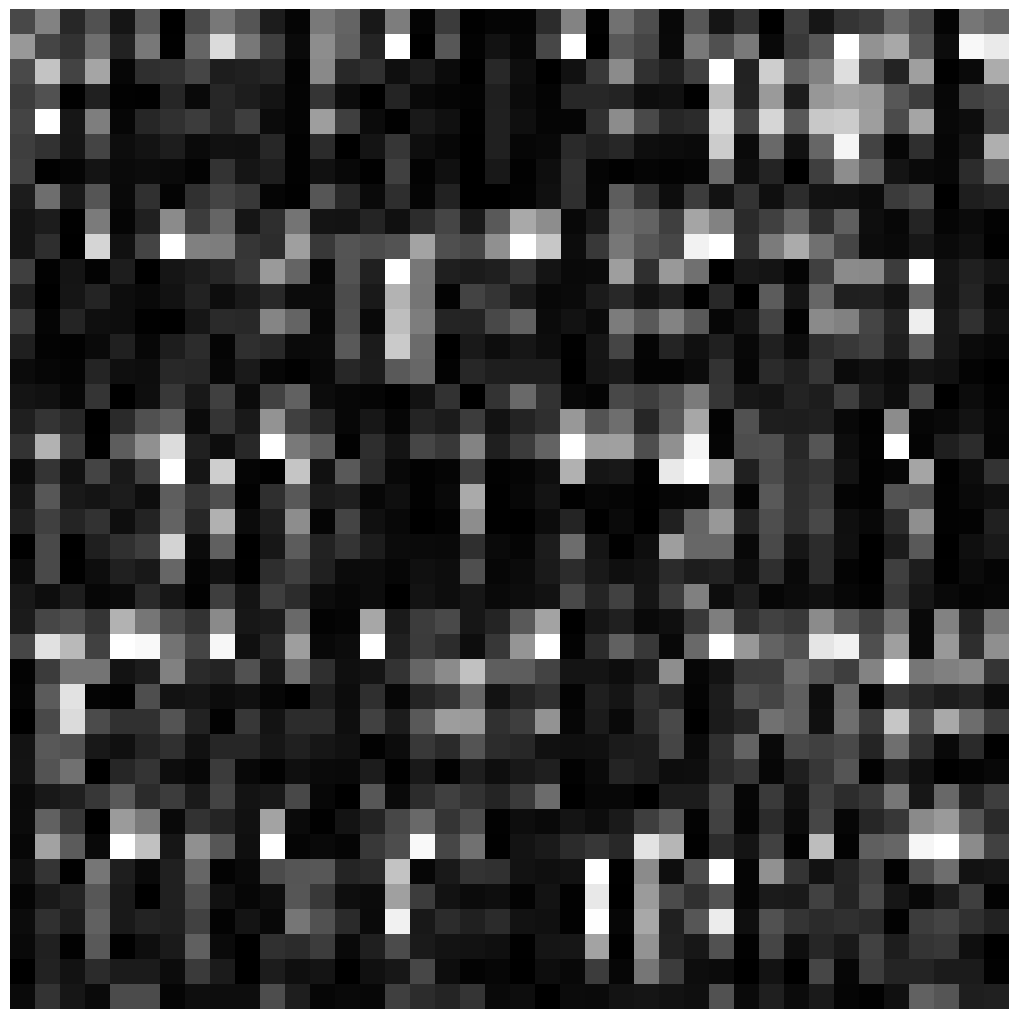

In [8]:
import matplotlib.pyplot as plt

def random_pure_states(n, dim):
    real = torch.randn(n, dim, dtype=torch.float64)
    imag = torch.randn(n, dim, dtype=torch.float64)
    v = (real + 1j * imag).to(torch.complex128)
    v = v / v.norm(dim=1, keepdim=True)
    return v

def density_diag_to_image(rho_batch):
    probs = rho_batch.diagonal(dim1=-2, dim2=-1).real.clamp(min=0)
    probs = probs / probs.sum(dim=-1, keepdim=True)
    return probs.reshape(-1, res, res)

model.eval()
with torch.no_grad():
    z = random_pure_states(25, 2 ** model.n_latent).to(device)
    latent_rho = to_density_matrices(z)
    gen_data = model.decode(latent_rho)
    gen_data = density_diag_to_image(gen_data).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(gen_data[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing reconstructions

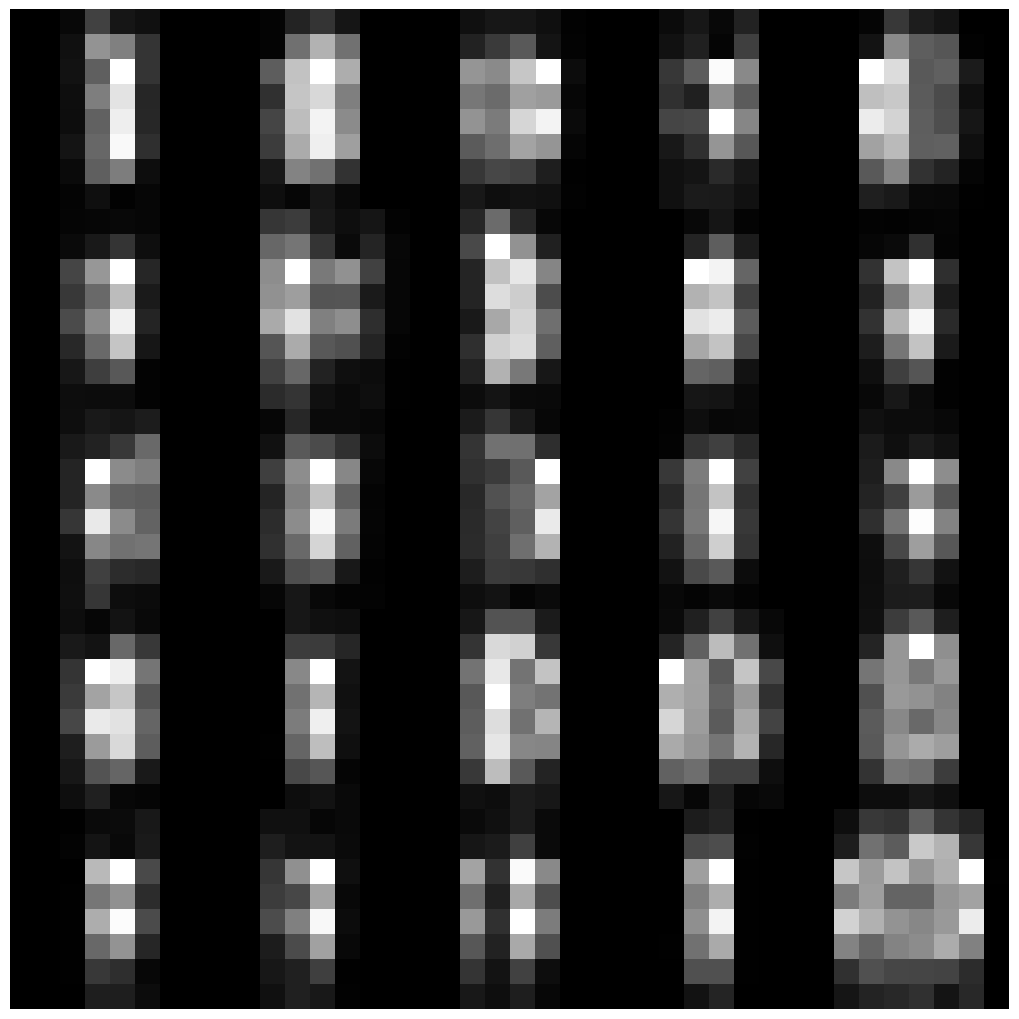

In [9]:
eval_x = eval_dataset[:25].to(device)
with torch.no_grad():
    eval_rho = to_density_matrices(eval_x)
    recon, _ = model(eval_rho)
    reconstructions = density_diag_to_image(recon).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

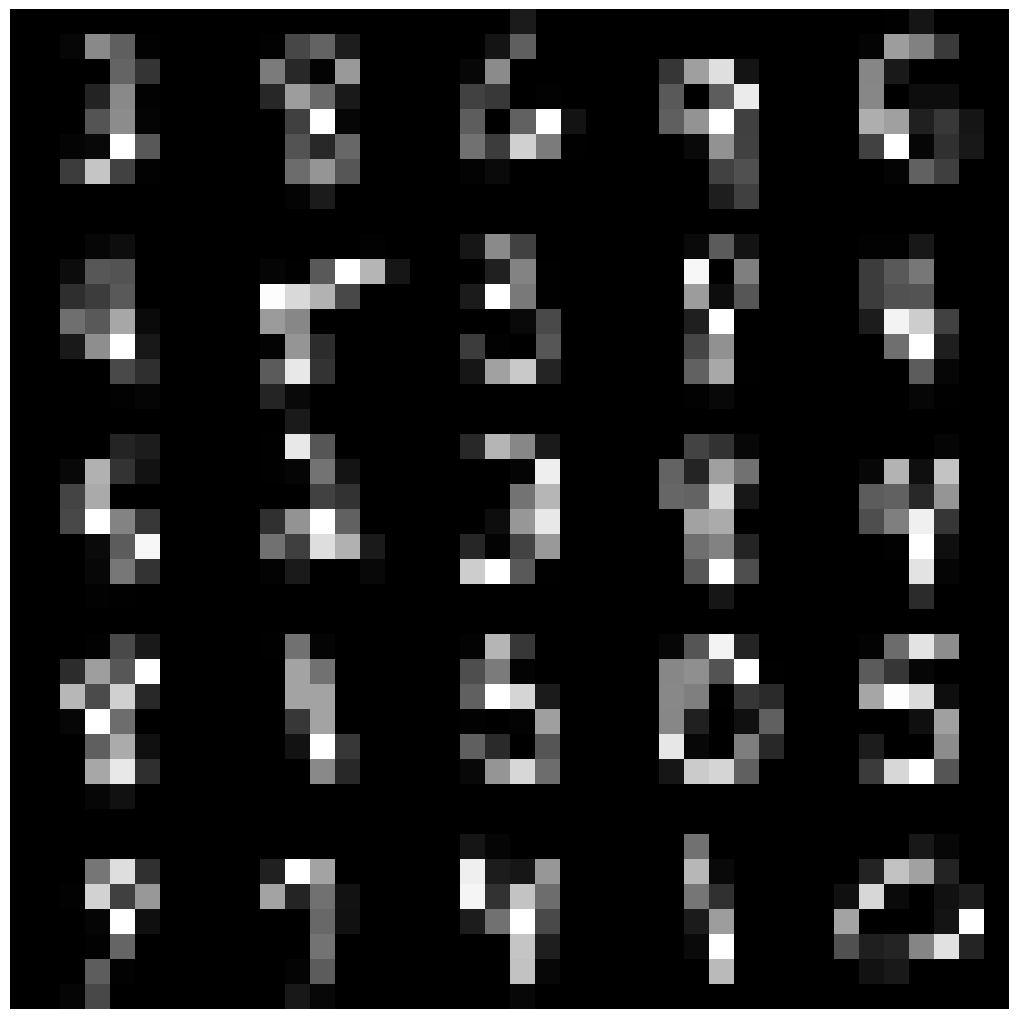

In [10]:
# show the true data
true_images = (eval_x.cpu() ** 2).reshape(-1, res, res)  # amplitudes^2 = pixel probabilities

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(true_images[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing interpolations

The official repo has no interpolation utility. Since latents here are density matrices rather
than a vector space, linear (convex) interpolation between two latent density matrices —
`(1-a) rho1 + a rho2`, itself always a valid density matrix — is the natural analogue of the
Gaussian-latent interpolation used in `vae.ipynb`.

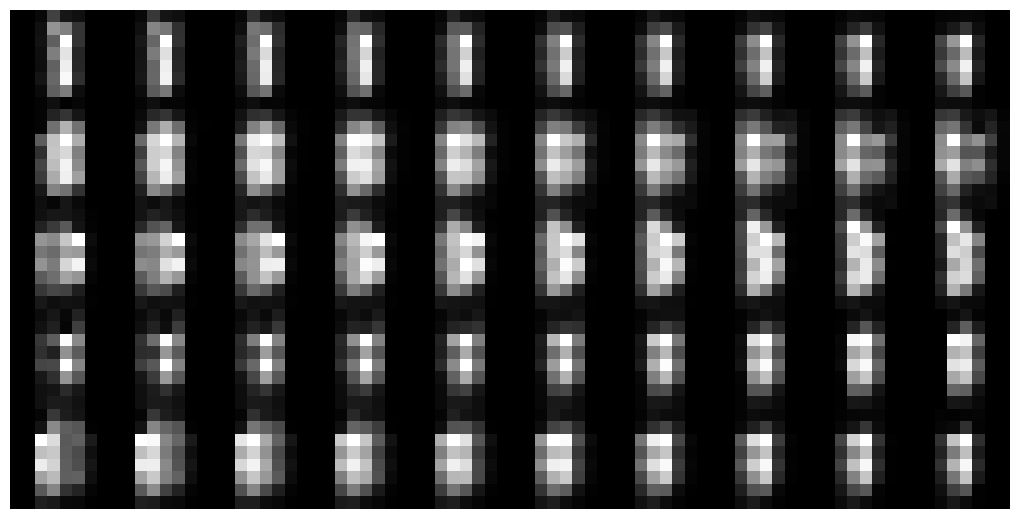

In [11]:
x1 = eval_dataset[:5].to(device)
x2 = eval_dataset[5:10].to(device)

with torch.no_grad():
    z1 = model.encode(to_density_matrices(x1))
    z2 = model.encode(to_density_matrices(x2))

    granularity = 10
    alphas = torch.linspace(0, 1, granularity, device=device)
    frames = []
    for a in alphas:
        z_interp = (1 - a) * z1 + a * z2
        frames.append(model.decode(z_interp))
    interpolations = torch.stack(frames)  # (granularity, 5, dim, dim)
    interpolations = density_diag_to_image(interpolations.reshape(-1, *interpolations.shape[-2:]))
    interpolations = interpolations.reshape(granularity, 5, res, res).permute(1, 0, 2, 3).cpu()

fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))
for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)